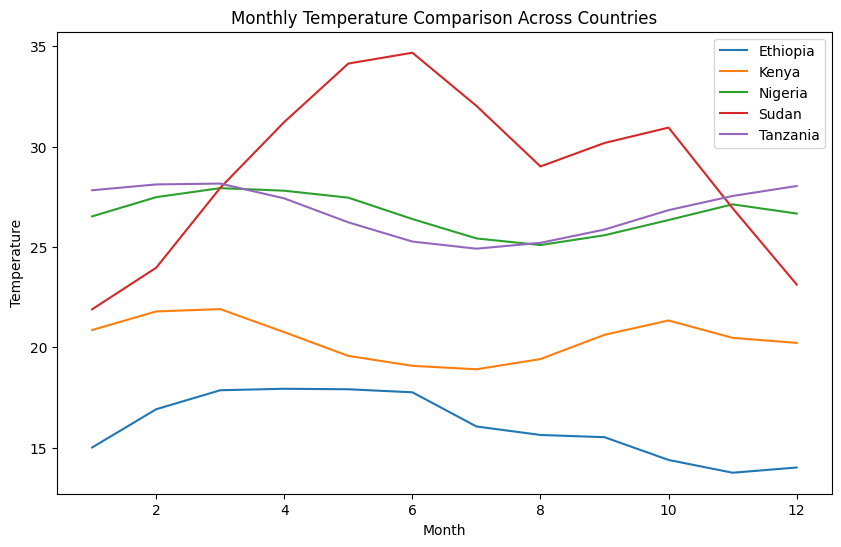

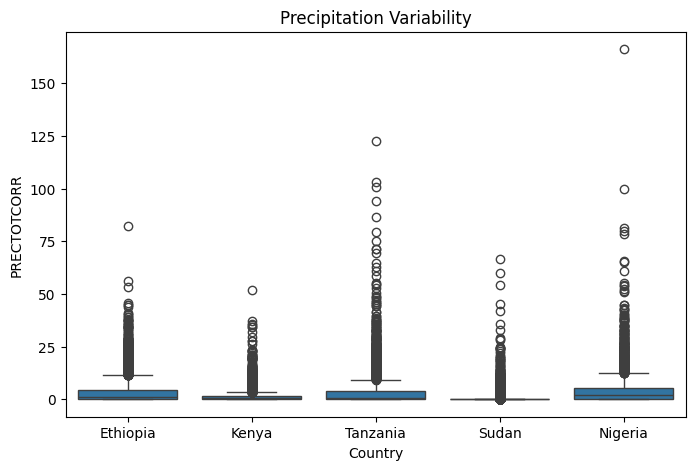

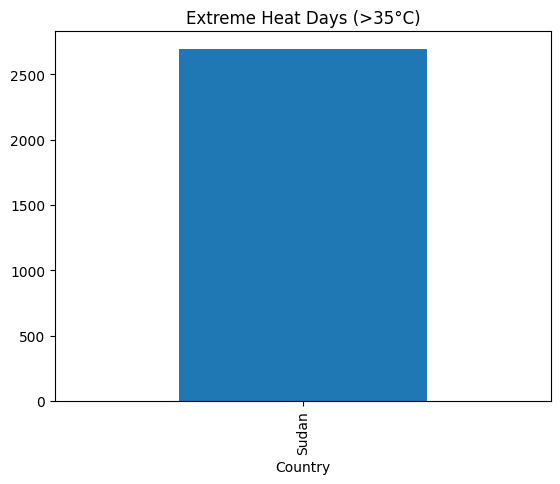

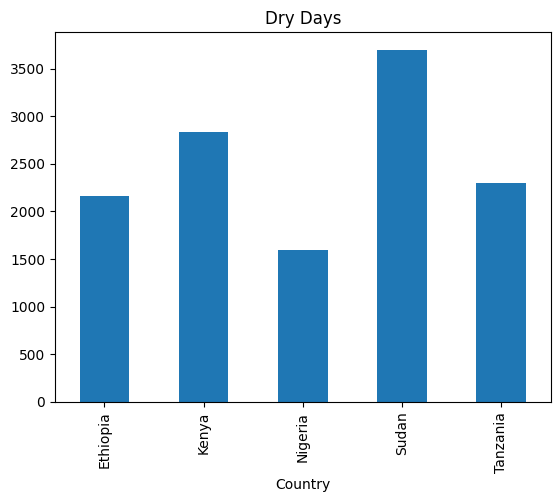

               mean  median       std
Country                              
Ethiopia  16.068500   16.04  1.898050
Kenya     20.427600   20.36  1.440824
Nigeria   26.656928   26.82  1.123335
Sudan     28.759007   29.16  4.681305
Tanzania  26.802422   26.99  1.325388
              mean  median       std
Country                             
Ethiopia  3.633795    0.82  6.289061
Kenya     1.468162    0.38  3.180228
Nigeria   4.213914    1.84  7.266742
Sudan     0.643875    0.00  3.057672
Tanzania  3.740256    0.64  8.003947
ANOVA p-value: 0.0
           MeanTemp   TempStd  HotDays  DryDays        Score
Country                                                     
Sudan     28.759007  4.681305   2694.0     3696  6423.440312
Ethiopia  16.068500  1.898050      NaN     2161          NaN
Kenya     20.427600  1.440824      NaN     2831          NaN
Nigeria   26.656928  1.123335      NaN     1595          NaN
Tanzania  26.802422  1.325388      NaN     2303          NaN


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway

ethiopia = pd.read_csv("data/ethiopia_clean.csv")
kenya = pd.read_csv("data/kenya_clean.csv")
tanzania = pd.read_csv("data/tanzania_clean.csv")
uganda = pd.read_csv("data/sudan_clean.csv")
rwanda = pd.read_csv("data/nigeria_clean.csv")

df = pd.concat([ethiopia, kenya, tanzania, uganda, rwanda])

# Temperature trend
temp_country = df.groupby(["Country", "Month"])["T2M"].mean().reset_index()

plt.figure(figsize=(10,6))
for country in temp_country["Country"].unique():
    data = temp_country[temp_country["Country"] == country]
    plt.plot(data["Month"], data["T2M"], label=country)

plt.title("Monthly Temperature Comparison Across Countries")
plt.xlabel("Month")
plt.ylabel("Temperature")
plt.legend()
plt.show()

# Rainfall boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x="Country", y="PRECTOTCORR", data=df)
plt.title("Precipitation Variability")
plt.show()

# Extreme heat
hot_days = df[df["T2M_MAX"] > 35].groupby("Country").size()

hot_days.plot(kind="bar")
plt.title("Extreme Heat Days (>35°C)")
plt.show()

# Dry days
dry_days = df[df["PRECTOTCORR"] < 1].groupby("Country").size()

dry_days.plot(kind="bar")
plt.title("Dry Days")
plt.show()

# Summary tables
temp_stats = df.groupby("Country")["T2M"].agg(["mean", "median", "std"])
rain_stats = df.groupby("Country")["PRECTOTCORR"].agg(["mean", "median", "std"])

print(temp_stats)
print(rain_stats)

# ANOVA
groups = [df[df["Country"] == c]["T2M"].dropna() for c in df["Country"].unique()]
stat, p = f_oneway(*groups)

print("ANOVA p-value:", p)

# Vulnerability
vulnerability = pd.DataFrame({
    "MeanTemp": temp_stats["mean"],
    "TempStd": temp_stats["std"],
    "HotDays": hot_days,
    "DryDays": dry_days
})

vulnerability["Score"] = (
    vulnerability["MeanTemp"] +
    vulnerability["TempStd"] +
    vulnerability["HotDays"] +
    vulnerability["DryDays"]
)

print(vulnerability.sort_values("Score", ascending=False))

## COP32 Climate Vulnerability Insights

Based on the cross-country climate analysis, the following key insights emerge:

- Countries with consistently high temperatures and frequent extreme heat events face the greatest heat stress risk.
- High precipitation variability indicates increased exposure to floods and drought cycles, making climate adaptation more difficult.
- Countries with high numbers of dry days are more vulnerable to agricultural and water resource stress.
- Ethiopia’s climate profile shows moderate temperature levels but seasonal rainfall variability compared to its neighbors.
- Based on combined indicators, countries experiencing both high heat and high rainfall instability should be prioritized for climate adaptation financing at COP32.

## Statistical Test Insight

The ANOVA test was used to determine whether temperature differences across countries are statistically significant.

The resulting p-value indicates whether we can reject the null hypothesis that all countries share the same mean temperature. A low p-value suggests significant climatic differences between countries.